# Conflict-Event → Road-Blockage Probability — Impact Model

**ACLED Afghanistan, 2017–2026 (69,655 events).** This notebook turns conflict events into
per-location **road-blockage probabilities**. It mirrors `docs/methodology.md` and uses the
framework core in the `c2rb` package. Parameters are **layered**: the country-independent physics
lives in `params.base.yaml`, and country-local settings (data paths, calibrated `P0`) live
in `countries/afghanistan.yaml`; `c2rb.load_config` merges them.

Pipeline: `event → effective buffer radius R_eff → distance-decay kernel → P(block|d) →
noisy-OR over nearby events (with temporal decay) → P(road blocked)`.

The central idea — **the buffer zone must vary by `sub_event_type`** — is *calibrated from the
ground-truth `is_road_blocked` label* (Section 3). The same calibration runs headless via
`python train.py --config countries/afghanistan.yaml` (see `docs/COUNTRY_GUIDE.md`).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import c2rb

plt.rcParams["figure.dpi"] = 110
CFG_RAW = c2rb.load_config("countries/afghanistan.yaml")  # base + country override, merged
cfg = c2rb.config_from_yaml(CFG_RAW)

df = pd.read_csv(CFG_RAW["paths"]["acled_csv"], encoding="utf-8-sig", low_memory=False)
df = c2rb.prepare_events(df)   # parse event_date, type fatalities, derive civ_flag
print(f"Loaded {len(df):,} events | {df.event_date.min().date()} → {df.event_date.max().date()}")
print(f"Country: {df.country.unique()} | sub_event_types: {df.sub_event_type.nunique()}")
df[["event_date","sub_event_type","fatalities","geo_precision","latitude","longitude"]].head()

Loaded 69,655 events | 2017-01-01 → 2026-06-12
Country: <ArrowStringArray>
['Afghanistan']
Length: 1, dtype: str | sub_event_types: 24


,event_date,sub_event_type,fatalities,geo_precision,latitude,longitude
0,2017-01-01,Remote explosive/landmine/IED,1,1,34.3482,62.1997
1,2017-01-01,Shelling/artillery/missile attack,0,1,34.5658,69.2131
2,2017-01-01,Armed clash,0,2,36.2224,69.1504
3,2017-01-01,Air/drone strike,18,1,33.8483,68.8310
4,2017-01-01,Air/drone strike,7,3,32.1058,66.9083


## 1. Profile the data

What kinds of events, how deadly, how precisely located. The `geo_precision` distribution is
important — it feeds the locational-uncertainty term `R_geo`.

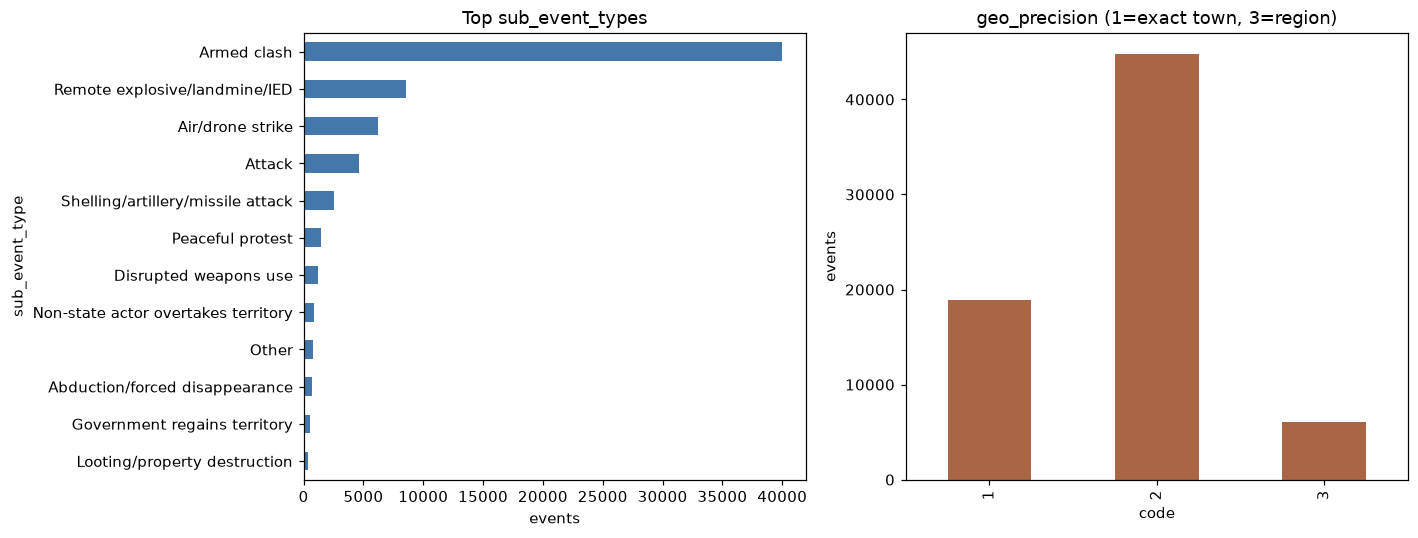

Fatalities — total: 204,181 | mean/event: 2.93 | max: 269


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
df.sub_event_type.value_counts().head(12).iloc[::-1].plot.barh(ax=ax[0], color="#4477aa")
ax[0].set_title("Top sub_event_types"); ax[0].set_xlabel("events")
df.geo_precision.value_counts().sort_index().plot.bar(ax=ax[1], color="#aa6644")
ax[1].set_title("geo_precision (1=exact town, 3=region)"); ax[1].set_xlabel("code"); ax[1].set_ylabel("events")
plt.tight_layout(); plt.show()
print("Fatalities — total: {:,} | mean/event: {:.2f} | max: {}".format(
      df.fatalities.sum(), df.fatalities.mean(), df.fatalities.max()))

## 2. Load the ground-truth labels

The classified export adds two human-verified yes/no columns:

- **`is_road_affected`** — the event impacted a road in any way (broad).
- **`is_road_blocked`** — a road was actually closed / made impassable (narrow). **This is our
  calibration & scoring target.**

We load them as 0/1 via `c2rb.load_labels`, then run a **consistency check**: blockage should
be a subset of being affected. The two also tell *different* stories, which justifies modelling
blockage specifically.

In [3]:
labels = c2rb.load_labels(df, CFG_RAW["paths"]["label_blocked_col"],
                          CFG_RAW["paths"]["label_affected_col"])
# overwrite the raw yes/no columns with the parsed 0/1 ints (same names)
for col in labels.columns:
    df[col] = labels[col].values
A, B = df["is_road_affected"], df["is_road_blocked"]
print(f"is_road_affected : {A.sum():,} yes ({100*A.mean():.1f}%)")
print(f"is_road_blocked  : {B.sum():,} yes ({100*B.mean():.2f}%)")
print("\nCross-tab (affected x blocked):")
print(pd.crosstab(A, B, rownames=["affected"], colnames=["blocked"]))
print(f"\nNesting check — blocked but NOT affected: {int(((B==1)&(A==0)).sum())} (should be ~0)")
print(f"P(blocked | affected) = {B[A==1].mean():.3f}")

is_road_affected : 14,456 yes (20.8%)
is_road_blocked  : 607 yes (0.87%)

Cross-tab (affected x blocked):
blocked       0    1
affected            
0         55198    1
1         13850  606

Nesting check — blocked but NOT affected: 1 (should be ~0)
P(blocked | affected) = 0.042


**Affected ≠ blocked.** The two labels diverge sharply by event type — the clearest evidence
that we must model *blockage* directly, not road-relatedness.

In [4]:
div = (df.groupby("sub_event_type")
         .agg(n=("is_road_blocked","size"),
              p_affected=("is_road_affected","mean"),
              p_blocked=("is_road_blocked","mean"))
         .sort_values("p_blocked", ascending=False))
print("Where AFFECTED and BLOCKED disagree most:")
print("  IED/landmine — affects roads a lot, blocks them rarely (roadside bomb, traffic resumes)")
print("  Protests / territorial control — block roads deliberately\n")
div.loc[["Remote explosive/landmine/IED","Suicide bomb","Violent demonstration",
         "Peaceful protest","Non-state actor overtakes territory","Air/drone strike"],
        ["n","p_affected","p_blocked"]].round(3)

Where AFFECTED and BLOCKED disagree most:
  IED/landmine — affects roads a lot, blocks them rarely (roadside bomb, traffic resumes)
  Protests / territorial control — block roads deliberately



,n,p_affected,p_blocked
sub_event_type,,,
Remote explosive/landmine/IED,8545,0.656,0.003
Suicide bomb,289,0.405,0.000
Violent demonstration,44,0.386,0.182
Peaceful protest,1454,0.102,0.061
Non-state actor overtakes territory,905,0.211,0.063
Air/drone strike,6249,0.049,0.001


## 3. Calibrate the peak blockage propensity `P0(s)`

`P0(s) = P(is_road_blocked | sub_event_type)`, smoothed with **Beta-Binomial empirical-Bayes
shrinkage** so small types (Headquarters or base established, Sexual violence) don't get unstable 0.000 rates. Beta
posterior 95% credible intervals show the uncertainty on the shrunk estimate. **This is the
headline answer to "how does blockage vary by type?"**

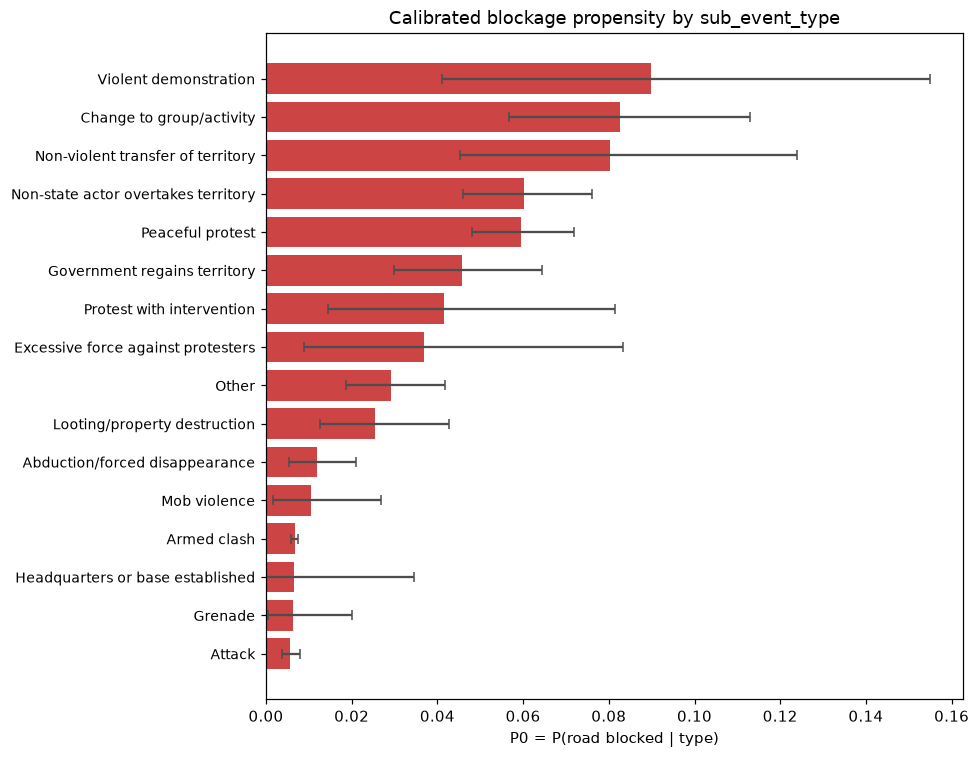

,pos,n,p0_raw,p0_shrunk,post_lo,post_hi
grp,,,,,,
Violent demonstration,8,44,0.1818,0.0897,0.0410,0.1549
Change to group/activity,30,318,0.0943,0.0827,0.0568,0.1129
Non-violent transfer of territory,14,130,0.1077,0.0802,0.0453,0.1239
Non-state actor overtakes territory,57,905,0.0630,0.0601,0.0460,0.0761
Peaceful protest,89,1454,0.0612,0.0595,0.0481,0.0720
Government regains territory,25,507,0.0493,0.0457,0.0299,0.0645
Protest with intervention,5,81,0.0617,0.0415,0.0145,0.0816
Excessive force against protesters,3,43,0.0698,0.0369,0.0089,0.0834
Other,23,753,0.0305,0.0292,0.0187,0.0419


In [5]:
p0tab = c2rb.empirical_bayes_p0(df["is_road_blocked"], df["sub_event_type"], prior_strength=50)
show = p0tab.head(16)
fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(show))
ax.barh(y, show["p0_shrunk"], color="#cc4444")
ax.errorbar(show["p0_shrunk"], y,
            xerr=[show["p0_shrunk"]-show["post_lo"], show["post_hi"]-show["p0_shrunk"]],
            fmt="none", ecolor="0.3", capsize=3)  # Beta posterior 95% credible interval
ax.set_yticks(y); ax.set_yticklabels(show.index, fontsize=9); ax.invert_yaxis()
ax.set_xlabel("P0 = P(road blocked | type)"); ax.set_title("Calibrated blockage propensity by sub_event_type")
plt.tight_layout(); plt.show()
p0tab[["pos","n","p0_raw","p0_shrunk","post_lo","post_hi"]].round(4).head(12)

**Result.** Protests and territorial-control events top the ranking (Violent demonstration,
Change-to-group, territory transfers) while IED/airstrike/suicide sit at the bottom — the
opposite of an *affected*-based ranking. A single fixed buffer would be wrong: the model must
be type-aware.

### 3.1 Validate — does the signal generalise? (supervised logistic regression)

With ground-truth labels this is now a *proper* supervised check. We train on event attributes
and report cross-validated **AUC** (discrimination), **PR-AUC** (precision/recall under the
0.87% imbalance), **Brier** (probability accuracy), and a **calibration curve**.

AUC    = 0.732
PR-AUC = 0.0423  (prevalence 0.0087)
Brier  = 0.00846  (no-skill baseline 0.00864)


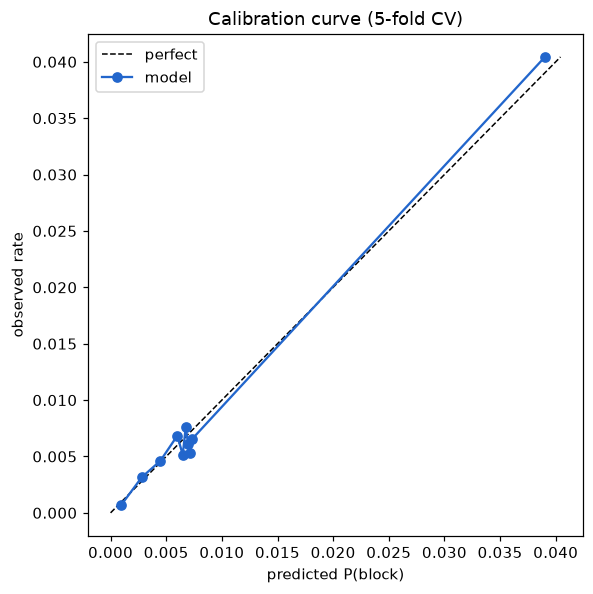

In [6]:
# Same 5-fold logistic-regression check that `train.py` runs, via the shared helper so the
# notebook and the CLI can never drift apart.
val = c2rb.validate_signal(df, "is_road_blocked", n_splits=5, seed=0)
print(f"AUC    = {val['auc']:.3f}")
print(f"PR-AUC = {val['pr_auc']:.4f}  (prevalence {val['prevalence']:.4f})")
print(f"Brier  = {val['brier']:.5f}  (no-skill baseline {val['brier_baseline']:.5f})")

cal = val["calibration"]
fig, ax = plt.subplots(figsize=(5.5, 5.5))
hi = float(max(cal["pred"].max(), cal["obs"].max()))
ax.plot([0, hi], [0, hi], "k--", lw=1, label="perfect")
ax.plot(cal["pred"], cal["obs"], "o-", color="#2266cc", label="model")
ax.set_xlabel("predicted P(block)"); ax.set_ylabel("observed rate")
ax.set_title("Calibration curve (5-fold CV)"); ax.legend(); plt.tight_layout(); plt.show()

AUC ≈ 0.73 with Brier *below* the no-skill baseline and points near the diagonal ⇒ the model is
discriminative and well-calibrated even under heavy class imbalance, so the `P0` values are
valid probabilities.

## 4. Locational uncertainty `R_geo` — why we use ACLED's documented values

We *try* to estimate `R_geo` empirically from the coordinate spread of events sharing a
`location` name. In this dataset that spread is ~0 km — ACLED snaps same-location events to one
centroid — so the estimate is uninformative and we fall back to ACLED's documented precision
semantics (1 / 5 / 25 km). This is an honest data limitation, not a modelling choice.

In [7]:
def spread75(g):
    if len(g) < 3: return np.nan
    d = c2rb.haversine_km(g.latitude, g.longitude, g.latitude.median(), g.longitude.median())
    return np.percentile(d, 75)
for gp in sorted(df.geo_precision.unique()):
    s = df[df.geo_precision==gp].groupby("location").apply(spread75, include_groups=False).dropna()
    print(f"geo_precision={gp}: empirical 75th-pct spread ≈ {s.median():.2f} km  → using R_geo={cfg.r_geo[gp]} km")

geo_precision=1: empirical 75th-pct spread ≈ 0.00 km  → using R_geo=1.0 km
geo_precision=2: empirical 75th-pct spread ≈ 0.00 km  → using R_geo=5.0 km
geo_precision=3: empirical 75th-pct spread ≈ 0.00 km  → using R_geo=25.0 km


## 5. Effective radius and decay kernels

`R_eff = sqrt(R_phys² + R_geo²) · severity_multiplier`. The decay kernel *shape* is chosen per
type (Gaussian for blasts, exponential for battles, uniform for protests). Below: the kernels,
and example radii showing how low precision (geo 3) inflates the zone.

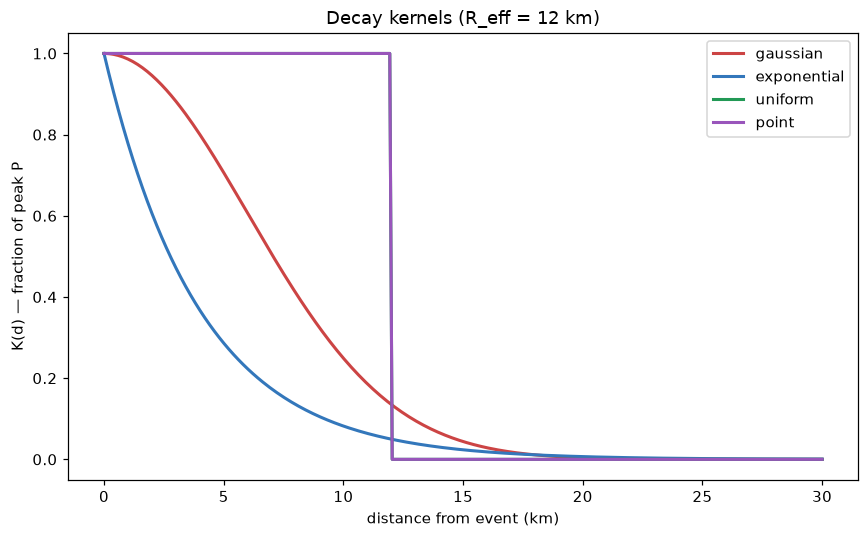

,sub_event_type,geo_prec,R_eff_km,kernel,P0
0,Remote explosive/landmine/IED,1,1.5,gaussian,0.0033
1,Remote explosive/landmine/IED,3,26.8,gaussian,0.0033
2,Suicide bomb,1,2.4,gaussian,0.0013
3,Suicide bomb,3,26.9,gaussian,0.0013
4,Armed clash,1,16.1,exponential,0.0067
5,Armed clash,3,31.2,exponential,0.0067
6,Air/drone strike,1,3.4,gaussian,0.0007
7,Air/drone strike,3,27.0,gaussian,0.0007
8,Peaceful protest,1,4.4,uniform,0.0595
9,Peaceful protest,3,27.1,uniform,0.0595


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
d = np.linspace(0, 30, 300)
for kind, col in [("gaussian","#cc4444"),("exponential","#3377bb"),("uniform","#229955"),("point","#9955bb")]:
    ax.plot(d, c2rb.kernel(d, 12.0, kind), label=kind, color=col, lw=2)
ax.set_xlabel("distance from event (km)"); ax.set_ylabel("K(d) — fraction of peak P")
ax.set_title("Decay kernels (R_eff = 12 km)"); ax.legend(); plt.tight_layout(); plt.show()

rows = []
for s in ["Remote explosive/landmine/IED","Suicide bomb","Armed clash","Air/drone strike","Peaceful protest"]:
    for gp in (1, 3):
        r = c2rb.effective_radius([s],[gp],[2],[0],cfg)[0]
        rows.append((s, gp, round(r,1), cfg.decay.get(s), cfg.p0.get(s)))
pd.DataFrame(rows, columns=["sub_event_type","geo_prec","R_eff_km","kernel","P0"])

## 6. Score blockage probability over space

`c2rb.score_targets` scores any set of target points (road-segment midpoints, or a grid)
against all events via noisy-OR with temporal decay. **Without a road layer it runs on a grid**
(the design's fallback), producing a continuous risk surface. We score a recent window.

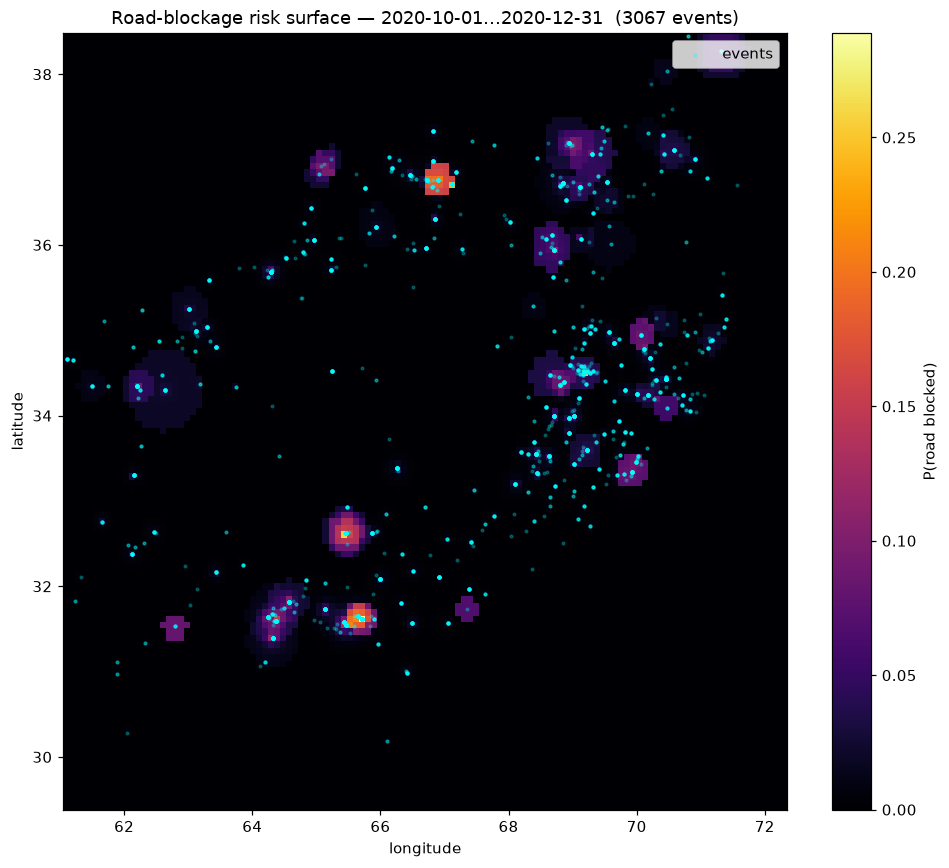

P(block): mean=0.004  max=0.289  cells>0.5: 0


In [9]:
AS_OF = "2020-12-31"; WINDOW_START = "2020-10-01"
events = df[(df.event_date >= WINDOW_START) & (df.event_date <= AS_OF)].copy()
nlat = nlon = 120
lat = np.linspace(df.latitude.min(), df.latitude.max(), nlat)
lon = np.linspace(df.longitude.min(), df.longitude.max(), nlon)
grid = pd.DataFrame([(a,b) for a in lat for b in lon], columns=["latitude","longitude"])
grid["p"] = c2rb.score_targets(events, grid, cfg, as_of_date=AS_OF)
P = grid["p"].values.reshape(nlat, nlon)

fig, ax = plt.subplots(figsize=(9, 8))
m = ax.pcolormesh(lon, lat, P, shading="auto", cmap="inferno", vmin=0, vmax=min(1, P.max()))
ax.scatter(events.longitude, events.latitude, s=3, c="cyan", alpha=0.25, label="events")
fig.colorbar(m, ax=ax, label="P(road blocked)")
ax.set_title(f"Road-blockage risk surface — {WINDOW_START}…{AS_OF}  ({len(events)} events)")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.legend(loc="upper right"); plt.tight_layout(); plt.show()
print(f"P(block): mean={grid.p.mean():.3f}  max={grid.p.max():.3f}  cells>0.5: {(grid.p>0.5).sum()}")

### 6.1 Road-layer mode (when you supply your 1 km segments)

Set `paths.roads` in `countries/afghanistan.yaml` to your segmented road file. The cell below loads it with
geopandas, scores each segment midpoint with the *same* `score_targets`, and runs the
"~70% of events within 1 km of a road" literature sanity check. It is skipped if no file is set.

Scored 27,991 road segments | events within 1 km of a road: 78%


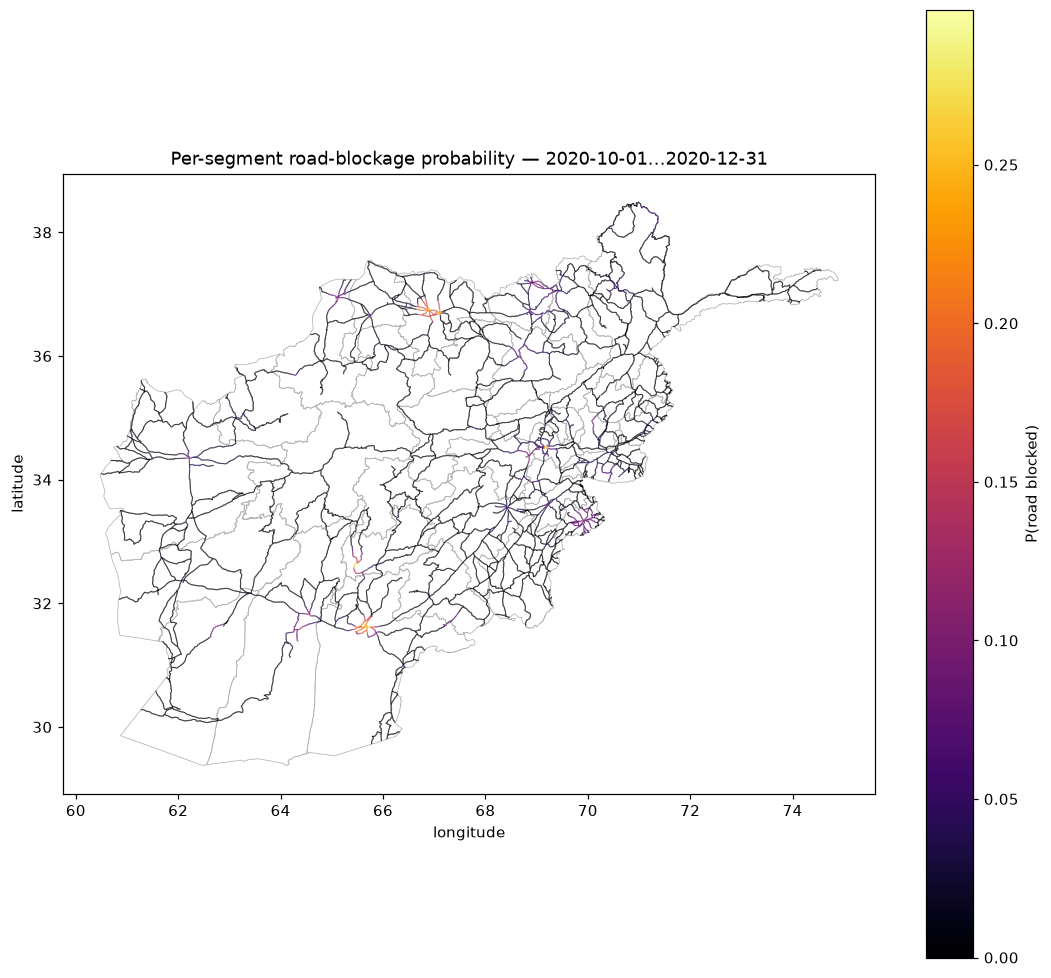

In [10]:
import os
roads_path = CFG_RAW["paths"].get("roads")
name_col = CFG_RAW["paths"].get("roads_name_col", "NAME_OF_RO")
admin_path = CFG_RAW["paths"].get("admin")
if roads_path and os.path.exists(roads_path):  # same guard as score.py: fall back to grid mode
    import geopandas as gpd
    roads = gpd.read_file(roads_path).to_crs(4326)
    mids = roads.geometry.representative_point()
    rt = pd.DataFrame({"latitude": mids.y.values, "longitude": mids.x.values})
    roads = roads.assign(p_block=c2rb.score_targets(events, rt, cfg, as_of_date=AS_OF))

    # Sanity check: share of events within 1 km of any road segment (~70% in the literature).
    lat0, lon0 = df.latitude.mean(), df.longitude.mean()
    ex, ey = c2rb.latlon_to_local_km(events.latitude, events.longitude, lat0, lon0)
    rx, ry = c2rb.latlon_to_local_km(rt.latitude, rt.longitude, lat0, lon0)
    near = [np.min(np.hypot(rx-ex[i], ry-ey[i])) <= 1.0 for i in range(len(events))]
    print(f"Scored {len(roads):,} road segments | events within 1 km of a road: {100*np.mean(near):.0f}%")

    fig, ax = plt.subplots(figsize=(10, 9))
    if admin_path and os.path.exists(admin_path):
        gpd.read_file(admin_path).to_crs(4326).boundary.plot(ax=ax, color="0.7", lw=0.5)
    roads.plot(column="p_block", cmap="inferno", legend=True, ax=ax, lw=0.7,
               legend_kwds={"label": "P(road blocked)"})
    ax.set_title(f"Per-segment road-blockage probability — {WINDOW_START}…{AS_OF}")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); plt.tight_layout(); plt.show()
else:
    print("No road layer configured (paths.roads = null). Running in grid mode — see Section 6.")
    roads = None

### 6.2 Which named roads are most likely blocked?

The concrete deliverable: rank road segments by blockage probability and roll up to named roads.

In [11]:
if roads is not None and name_col in roads:
    top = (roads[roads.p_block > 0]
           .groupby(name_col)
           .agg(max_p=("p_block","max"), mean_p=("p_block","mean"), segments=("p_block","size"))
           .sort_values("max_p", ascending=False).head(15).round(3))
    display(top)
    print(f"\nSegments with P(block) > 0.25: {(roads.p_block > 0.25).sum()} "
          f"of {len(roads):,}  ({100*(roads.p_block>0.25).mean():.1f}%)")
else:
    print("Road layer not loaded — see Section 6 grid output instead.")

,max_p,mean_p,segments
NAME_OF_RO,,,
Kandahr to Daman,0.299,0.182,21
Kandahr to Panjwaiy,0.297,0.185,51
Kabul to Maydan Shahr,0.291,0.096,38
Kabul to Surobi,0.289,0.031,67
Kabul to Bagrami,0.289,0.171,11
Kandahar to Arghandab,0.287,0.250,19
Kandhar to Zhera,0.283,0.221,21
Tirin Kot to Dehrawud,0.275,0.112,58
Dehrawud to Kejran,0.273,0.070,69



Segments with P(block) > 0.25: 49 of 27,991  (0.2%)


## 7. Sensitivity analysis

`P0` is *calibrated*, but `R_phys` and the kernel *shapes* are *assumptions*. This shows how the
high-risk footprint responds when we scale all physical radii up/down — making explicit what is
driven by assumptions vs. by the data.

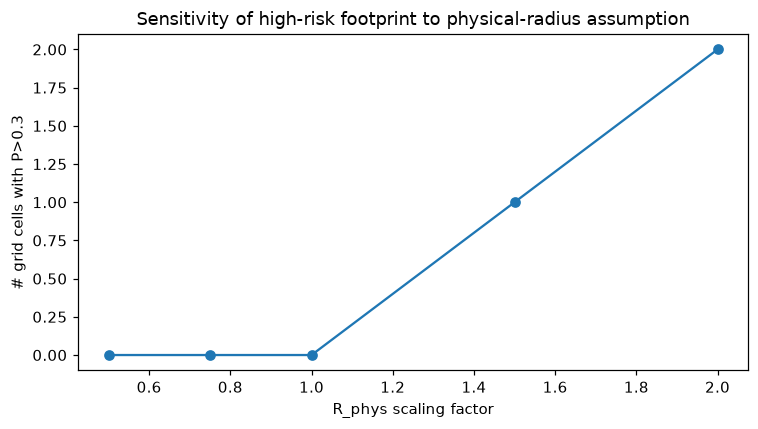

,R_phys_scale,mean_P,cells_P>0.3,max_P
0,0.50,0.002,0,0.262
1,0.75,0.002,0,0.276
2,1.00,0.004,0,0.289
3,1.50,0.007,1,0.311
4,2.00,0.012,2,0.331


In [12]:
import copy
base_cells = (grid.p > 0.3).sum()
out = []
for scale in [0.5, 0.75, 1.0, 1.5, 2.0]:
    c2 = copy.deepcopy(cfg); c2.r_phys = {k: v*scale for k, v in cfg.r_phys.items()}
    p = c2rb.score_targets(events, grid[["latitude","longitude"]], c2, as_of_date=AS_OF)
    out.append((scale, round(float(p.mean()),3), int((p>0.3).sum()), round(float(p.max()),3)))
sens = pd.DataFrame(out, columns=["R_phys_scale","mean_P","cells_P>0.3","max_P"])
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(sens.R_phys_scale, sens["cells_P>0.3"], "o-")
ax.set_xlabel("R_phys scaling factor"); ax.set_ylabel("# grid cells with P>0.3")
ax.set_title("Sensitivity of high-risk footprint to physical-radius assumption")
plt.tight_layout(); plt.show()
sens

## 8. Using the framework

- **Score given events** → `c2rb.score_targets(events, targets, cfg, as_of_date=...)`, or run
  `python score.py --config countries/afghanistan.yaml --as-of … --window-days …` for road
  rankings + a map.
- **Tune assumptions** → edit `params.base.yaml` (`R_phys`, decay class, severity, `tau_days`).
- **Re-calibrate `P0`** on a new classified export → `python train.py --config
  countries/afghanistan.yaml` writes the shrunk values straight back into the country config.
- **Localize to another country** → copy `countries/afghanistan.yaml`, point it at that country's
  CSV + roads, then `train.py` then `score.py`. See `docs/COUNTRY_GUIDE.md`.

See `docs/methodology.md` for the formulas, justification, and limitations.